# Ejemplo básico para explicar como funciona RSA

In [14]:
# RSA básico en Python

# 1. Elegimos dos primos
p = 11
q = 13

# 2. Calculamos n
n = p * q

# 3. Calculamos phi(n)
z = (p - 1) * (q - 1)

# 4. Elegimos e
e = 7

# 5. Calculamos d tal que e*d ≡ 1 mod z
#d = 103   # porque 7*103 = 721 y 721 mod 120 = 1
d = pow(e, -1, z) #algoritmo extendido de Euclides

print("Clave pública  (e, n) =", (e, n))
print("Clave privada (d, n) =", (d, n))

# Mensaje a cifrar
M = 9

# Cifrado: C = M^e mod n
C = pow(M, e, n)

# Descifrado: M = C^d mod n
M_descifrado = pow(C, d, n)

print("Mensaje original:", M)
print("Mensaje cifrado:", C)
print("Mensaje descifrado:", M_descifrado)
print("¿Coinciden?", M == M_descifrado)

Clave pública  (e, n) = (7, 143)
Clave privada (d, n) = (103, 143)
Mensaje original: 9
Mensaje cifrado: 48
Mensaje descifrado: 9
¿Coinciden? True


# Romper RSA con factorización
 
- Ejemplo con números pequeños para que sea factible.
-  Modificar bits_n para probar distinas longitudes de n

In [11]:
import random
import timeit
from sympy import isprime, mod_inverse, factorint


# ----------------------
# Generar primos p y q
# ----------------------
def generate_prime(bits):
    while True:
        candidate = random.randint(2**(bits-1), 2**bits - 1)
        if isprime(candidate):
            return candidate

# ----------------------
# Ataque con salida
# ----------------------
def romper_rsa_con_salida(n,c):
    factors = factorint(n)
    p_, q_ = list(factors.keys())
    z_ = (p_ - 1) * (q_ - 1)
    e = 65537
    
    d_ = mod_inverse(e, z_)
    m_recuperado = pow(c, d_, n)

    print("\n💥 Ataque: recuperación de mensaje sin clave privada")
    print(f"  Factores encontrados: p = {p_}, q = {q_}")
    print(f"  z(n) = {z_}")
    print(f"  d (calculado) = {d_}")
    print(f"  Mensaje recuperado (entero) = {m_recuperado}")

    try:
        texto_recuperado = m_recuperado.to_bytes((m_recuperado.bit_length() + 7) // 8, 'big').decode()
        print(f"  Mensaje en texto: {texto_recuperado}")
    except:
        print("  ❌ El mensaje no es texto ASCII válido.")


# ----------------------
# Medición con timeit
# ----------------------
def romper_rsa_sin_salida(n,c):
    factors = factorint(n)
    p_, q_ = list(factors.keys())
    e = 65537
    z_ = (p_ - 1) * (q_ - 1)
    d_ = mod_inverse(e, z_)
    return pow(c, d_, n)

def tiempoRupturaRSA(bits_n=20):
    
    bits_pq = bits_n // 2  # Aproximación

    p = generate_prime(bits_pq)
    q = generate_prime(bits_pq)
    n = p * q

    # Aseguramos que n tenga exactamente bits_n (o menos, si no se encuentra)
    while n.bit_length() > bits_n:
        p = generate_prime(bits_pq)
        q = generate_prime(bits_pq)
        n = p * q

    z = (p - 1) * (q - 1)
    e = 65537
    d = mod_inverse(e, z)

    mensaje = "ok"
    m = int.from_bytes(mensaje.encode(), byteorder='big')

    if m >= n:
        raise ValueError(f"❌ El mensaje ({m}) no cabe en n ({n}). Usa mensaje más corto o aumenta los bits con --bits")

    c = pow(m, e, n)

    # ----------------------
    # Mostrar claves y cifrado
    # ----------------------
    print("🔐 Claves generadas:")
    print(f"  p = {p}")
    print(f"  q = {q}")
    print(f"  n = {n} ({n.bit_length()} bits)")
    print(f"  e = {e}")
    print(f"  d = {d}")

    print(f"\n🧾 Mensaje original: {mensaje}")
    print(f"  Como entero: {m}")
    print(f"  Cifrado (c) = {c}")


    romper_rsa_con_salida(n,c)
    
    number = 10 # Número de repeticiones para medir el tiempo
    tiempo = timeit.timeit(lambda: romper_rsa_sin_salida(n,c), number=number)
    media = tiempo / number
    print(f"\n⏱️ Tiempo total para romper RSA {number} veces: {tiempo:.6f} segundos")
    print(f" 🕒 Tiempo promedio por ruptura: {media:.8f} segundos")

    return media


if __name__ == "__main__":
    tiempoRupturaRSA(bits_n=22)  # Puedes ajustar los bits con --bits

🔐 Claves generadas:
  p = 2017
  q = 1087
  n = 2192479 (22 bits)
  e = 65537
  d = 937025

🧾 Mensaje original: ok
  Como entero: 28523
  Cifrado (c) = 2163568

💥 Ataque: recuperación de mensaje sin clave privada
  Factores encontrados: p = 1087, q = 2017
  z(n) = 2189376
  d (calculado) = 937025
  Mensaje recuperado (entero) = 28523
  Mensaje en texto: ok

⏱️ Tiempo total para romper RSA 10 veces: 0.000781 segundos
 🕒 Tiempo promedio por ruptura: 0.00007807 segundos


# Estimación del tiempo de factorización

Predicciones:
-  256 bits -> 2282440.10 s (26.42 días)
-  512 bits -> 1.51e+17 s (4.78e+09 años)
- 1024 bits -> 6.57e+38 s (2.08e+31 años)
- 2048 bits -> 1.25e+82 s (3.96e+74 años)

🔐 Claves generadas:
  p = 1693
  q = 1523
  n = 2578439 (22 bits)
  e = 65537
  d = 2043377

🧾 Mensaje original: ok
  Como entero: 28523
  Cifrado (c) = 174137

💥 Ataque: recuperación de mensaje sin clave privada
  Factores encontrados: p = 1523, q = 1693
  z(n) = 2575224
  d (calculado) = 2043377
  Mensaje recuperado (entero) = 28523
  Mensaje en texto: ok

⏱️ Tiempo total para romper RSA 10 veces: 0.001106 segundos
 🕒 Tiempo promedio por ruptura: 0.00011060 segundos
Tiempo para 22 bits: 0.000111 segundos
🔐 Claves generadas:
  p = 860007232181
  q = 941378897219
  n = 809592659830914268204639 (80 bits)
  e = 65537
  d = 412486206331597544064793

🧾 Mensaje original: ok
  Como entero: 28523
  Cifrado (c) = 604377015514217991063773

💥 Ataque: recuperación de mensaje sin clave privada
  Factores encontrados: p = 860007232181, q = 941378897219
  z(n) = 809592659829112882075240
  d (calculado) = 412486206331597544064793
  Mensaje recuperado (entero) = 28523
  Mensaje en texto: ok

⏱️ Tiempo

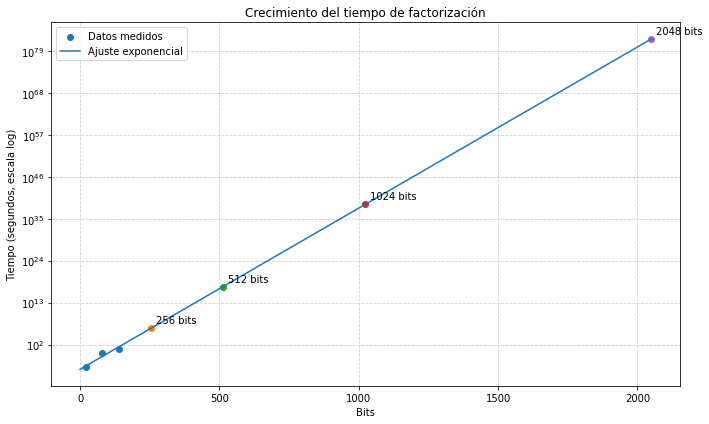

In [13]:
import numpy as np
import matplotlib.pyplot as plt

# Datos experimentales
bits = np.array([22, 80, 138], dtype=float)
tiempos = np.array([0.00028405, 0.76891385, 19.28555241], dtype=float)

tiempos[0] = tiempoRupturaRSA(bits_n=22)
print(f"Tiempo para 22 bits: {tiempos[0]:.6f} segundos")
tiempos[1] = tiempoRupturaRSA(bits_n=80)
print(f"Tiempo para 80 bits: {tiempos[1]:.6f} segundos")
tiempos[2] = tiempoRupturaRSA(bits_n=138)
print(f"Tiempo para 138 bits: {tiempos[2]:.6f} segundos")



# Ajuste exponencial: ln(t) = a + b·bits
log_t = np.log(tiempos)
b, a = np.polyfit(bits, log_t, 1)

def modelo_tiempo(n_bits):
    return float(np.exp(a + b * n_bits))

def formato_tiempo(seg):
    minuto = 60
    hora = 3600
    dia = 86400
    anio = 365.25 * dia

    if seg < minuto:
        return f"{seg:.6f} s"
    elif seg < hora:
        return f"{seg:.2f} s ({seg/minuto:.2f} min)"
    elif seg < dia:
        return f"{seg:.2f} s ({seg/hora:.2f} h)"
    elif seg < anio:
        return f"{seg:.2f} s ({seg/dia:.2f} días)"
    else:
        return f"{seg:.2e} s ({seg/anio:.2e} años)"

# Puntos a mostrar
bits_extra = [256, 512, 1024, 2048]

print("Modelo aproximado:")
print(f"t(bits) ≈ exp({a:.4f} + {b:.4f}·bits)")
print(f"Factor por bit ≈ {np.exp(b):.4f}")
print()

print("Tiempos medidos:")
for bb, tt in zip(bits, tiempos):
    print(f"{int(bb):>4} bits -> {formato_tiempo(tt)}")

print("\nPredicciones:")
for bb in bits_extra:
    tt = modelo_tiempo(bb)
    print(f"{bb:>4} bits -> {formato_tiempo(tt)}")

# Gráfica
bits_plot = np.linspace(0, 2050, 500)
tiempos_plot = np.exp(a + b * bits_plot)

plt.figure(figsize=(10, 6))
plt.scatter(bits, tiempos, label="Datos medidos")
plt.plot(bits_plot, tiempos_plot, label="Ajuste exponencial")

# Marcar puntos extrapolados
for bb in bits_extra:
    tt = modelo_tiempo(bb)
    plt.scatter(bb, tt)
    plt.annotate(f"{bb} bits", (bb, tt), textcoords="offset points", xytext=(5, 5))

plt.yscale("log")
plt.xlabel("Bits")
plt.ylabel("Tiempo (segundos, escala log)")
plt.title("Crecimiento del tiempo de factorización")
plt.grid(True, which="both", linestyle="--", alpha=0.6)
plt.legend()
plt.tight_layout()
plt.show()